# EDA + Analysis

In [4]:
import pandas as pd

# Load Data

In [8]:
leads = pd.read_csv("Leadss.csv")
followups = pd.read_csv("Followups.csv")
conversions = pd.read_csv("Conversions.csv")
ads = pd.read_csv("Ads.csv")

 # Check Data

In [24]:
leads.head()

followups.head()

conversions.head()

,Lead_ID,Converted,Revenue_INR,Days_To_Convert
0,L0001,0,0,NaN
1,L0002,0,0,NaN
2,L0003,0,0,NaN
3,L0004,1,288012,41.0
4,L0005,0,0,NaN


# Check Missing Values

In [27]:
leads.isnull().sum()

Lead_ID        0
Lead_Date      0
Lead_Source    0
Industry       0
City           0
Assigned_To    0
Lead_Status    0
dtype: int64

In [29]:
followups.isnull().sum()

Lead_ID                   0
Followup_Count            0
Last_Followup_Days_Ago    0
Response                  0
dtype: int64

In [31]:
conversions.isnull().sum()

Lead_ID              0
Converted            0
Revenue_INR          0
Days_To_Convert    402
dtype: int64

# Merge Tables

In [34]:
df = leads.merge(
    followups,
    on="Lead_ID"
)

df = df.merge(
    conversions,
    on="Lead_ID"
)

df.head()

,Lead_ID,Lead_Date,Lead_Source,Industry,City,Assigned_To,Lead_Status,Followup_Count,Last_Followup_Days_Ago,Response,Converted,Revenue_INR,Days_To_Convert
0,L0001,2025-06-18,Google Ads,Education,Mumbai,Neha,Converted,6,6,Not Interested,0,0,NaN
1,L0002,2025-03-17,Website,Manufacturing,Delhi,Riya,Converted,4,16,Call Back,0,0,NaN
2,L0003,2025-01-18,Email Campaign,Education,Hyderabad,Vikas,Lost,3,49,Meeting Scheduled,0,0,NaN
3,L0004,2025-04-22,Website,Retail,Hyderabad,Karan,New,1,46,No Response,1,288012,41.0
4,L0005,2025-03-16,Email Campaign,Healthcare,Hyderabad,Karan,Converted,5,43,Meeting Scheduled,0,0,NaN


# Total Leads

In [37]:
df["Lead_ID"].nunique()

500

# Total Revenue

In [40]:
df["Revenue_INR"].sum()

np.int64(15444655)

# Total Converted

In [43]:
df["Converted"].sum()

np.int64(98)

# Conversion Rate

In [46]:
(df["Converted"].sum() /
 df["Lead_ID"].count())*100

np.float64(19.6)

 # Source Analysis

In [50]:
source_analysis = df.groupby(
    "Lead_Source"
).agg(
    Leads=("Lead_ID","count"),
    Revenue=("Revenue_INR","sum"),
    Conversions=("Converted","sum")
)

source_analysis

,Leads,Revenue,Conversions
Lead_Source,,,
Email Campaign,93,2243905,16
Facebook Ads,74,3074506,16
Google Ads,76,2025877,13
LinkedIn,84,1955902,12
Referral,77,2261064,16
Website,96,3883401,25


# Salesperson Analysis

In [54]:
salesperson_analysis = df.groupby(
    "Assigned_To"
).agg(
    Revenue=("Revenue_INR","sum"),
    Conversions=("Converted","sum")
)

salesperson_analysis

,Revenue,Conversions
Assigned_To,,
Aman,2866051,22
Karan,3938228,26
Neha,2243033,12
Riya,3144321,18
Vikas,3253022,20


# Follow-up Analysis

In [57]:
followup_analysis = df.groupby(
    "Followup_Count"
).agg(
    Conversion=("Converted","mean")
)

followup_analysis

,Conversion
Followup_Count,
0,0.265306
1,0.150000
2,0.272727
3,0.153846
4,0.268293
5,0.170732
6,0.170732
7,0.195652
8,0.188679


# Visualizations

In [60]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Simra\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


# Revenue Distribution

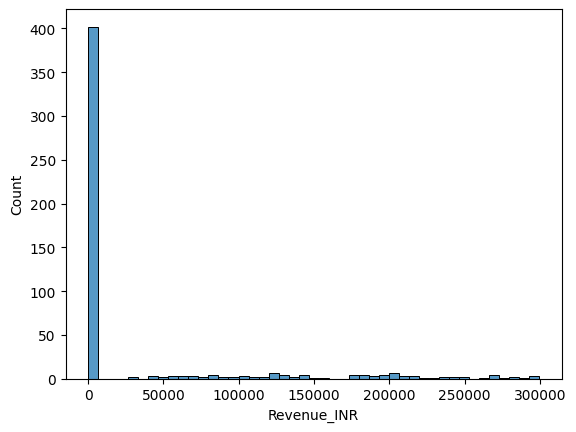

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    df["Revenue_INR"]
)

plt.show()

# Conversion Rate by Source

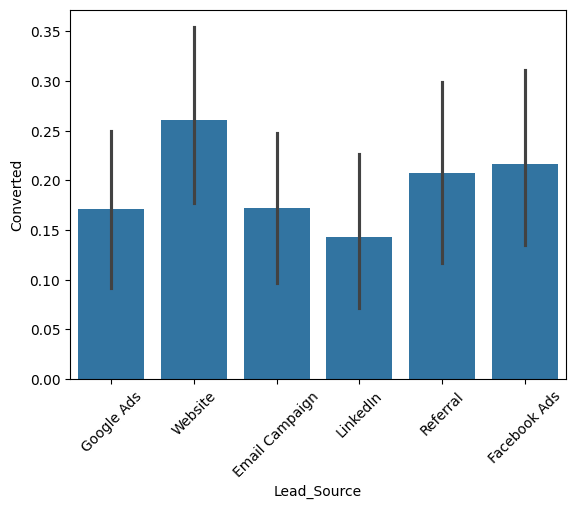

In [66]:
sns.barplot(
    data=df,
    x="Lead_Source",
    y="Converted"
)

plt.xticks(rotation=45)

plt.show()

# Follow-up Effectiveness

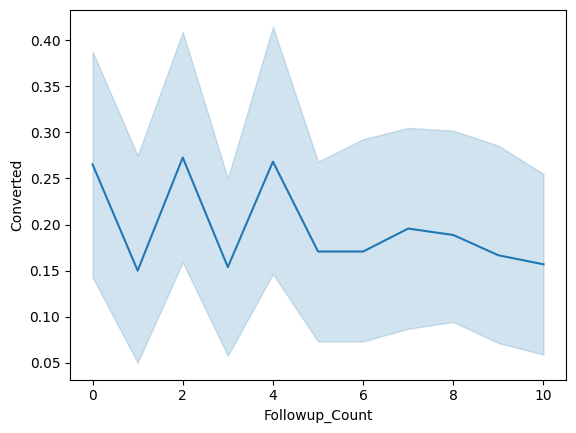

In [69]:
sns.lineplot(
    data=df,
    x="Followup_Count",
    y="Converted"
)

plt.show()